In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/ML-FinalAss/Walmart-Sales-Forecasting"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ML-FinalAss/Walmart-Sales-Forecasting


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.features.preprocessing import merge_and_enrich

train = pd.read_csv("data/train.csv")
stores = pd.read_csv("data/stores.csv")
features = pd.read_csv("data/features.csv")

df_clean = merge_and_enrich(train, stores, features)
print(f"Cleaned frame shape: {df_clean.shape}")
df_clean.head()

Cleaned frame shape: (421570, 20)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2010,2,5,5
1,1,1,2010-02-12,46039.49,1,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2010,2,6,12
2,1,1,2010-02-19,41595.55,0,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2010,2,7,19
3,1,1,2010-02-26,19403.54,0,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,2010,2,8,26
4,1,1,2010-03-05,21827.90,0,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,2010,3,9,5


/tmp/ipykernel_8726/3068897267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df_clean, estimator=np.mean, errorbar=None, palette='muted')


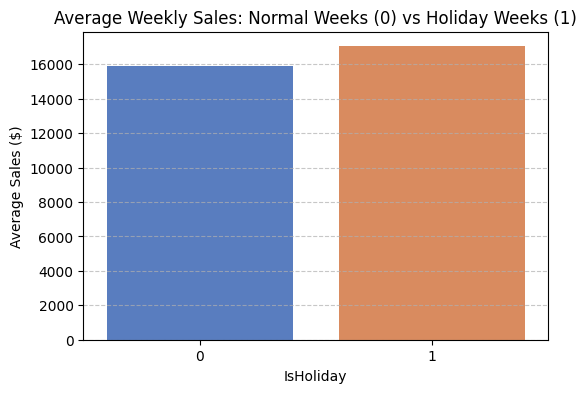

Holiday weeks average $17,035.82 vs Regular weeks average $15,901.45


In [3]:
plt.figure(figsize=(6, 4))
sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df_clean, estimator=np.mean, errorbar=None, palette='muted')
plt.title('Average Weekly Sales: Normal Weeks (0) vs Holiday Weeks (1)')
plt.ylabel('Average Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

holiday_means = df_clean.groupby('IsHoliday')['Weekly_Sales'].mean()
print(f"Holiday weeks average ${holiday_means[1]:,.2f} vs Regular weeks average ${holiday_means[0]:,.2f}")

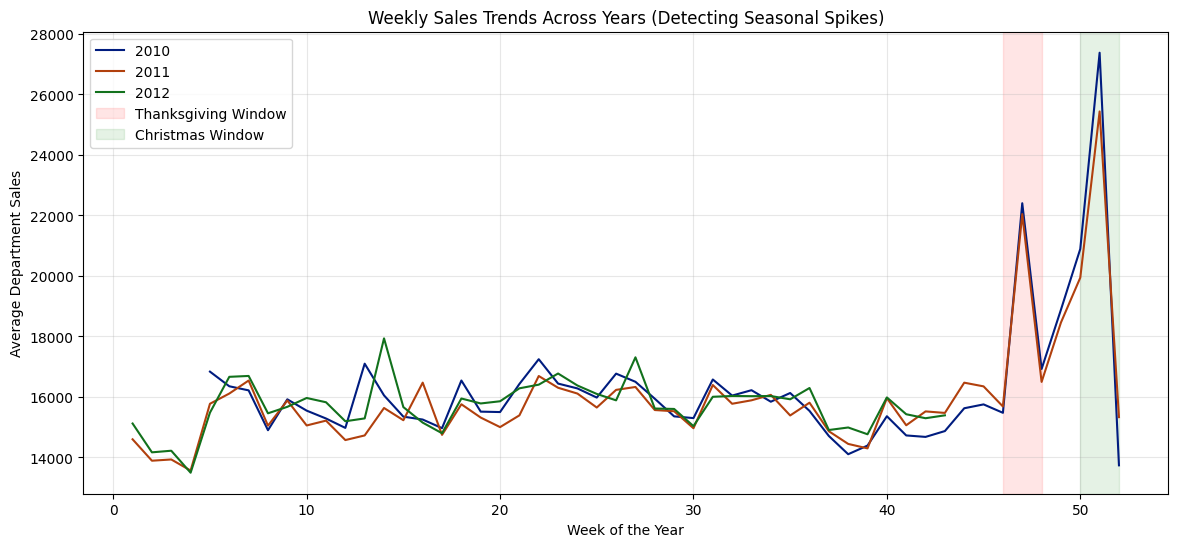

In [4]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='Week', y='Weekly_Sales', hue='Year', data=df_clean, palette='dark', errorbar=None)
plt.axvspan(46, 48, color='red', alpha=0.1, label='Thanksgiving Window')
plt.axvspan(50, 52, color='green', alpha=0.1, label='Christmas Window')
plt.title('Weekly Sales Trends Across Years (Detecting Seasonal Spikes)')
plt.xlabel('Week of the Year')
plt.ylabel('Average Department Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
print("Minimum Date:", df_clean['Date'].min())
print("Maximum Date:", df_clean['Date'].max())

Minimum Date: 2010-02-05 00:00:00
Maximum Date: 2012-10-26 00:00:00


In [6]:
train_mask = df_clean['Date'] < '2012-01-01'
val_mask = df_clean['Date'] >= '2012-01-01'

X_train_raw = df_clean[train_mask]
X_val_raw = df_clean[val_mask]

print(f"Training sample size (2010-2011): {X_train_raw.shape[0]}")
print(f"Validation sample size (2012): {X_val_raw.shape[0]}")

Training sample size (2010-2011): 294132
Validation sample size (2012): 127438
